In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def MMI(t=0.5):
    """
    MMI 2x2 con splitting ratio variable.
    
    Parámetro:
        t : fracción de potencia en BAR (0 <= t <= 1)
    
    Retorna:
        matriz 2x2 compleja unitaria
    """
    k = 1 - t
    
    return np.array([
        [np.sqrt(t), 1j * np.sqrt(k)],
        [1j * np.sqrt(k), np.sqrt(t)]
    ])

def phase_shifter(wl, delta_L, n_eff):
    phi = 2 * np.pi * n_eff * delta_L * (1/wl)
    return np.array([[np.exp(1j * phi), 0],
                     [0, 1]])

def phase_shifter_T(wl, delta_L, n_eff, alpha):
    beta = 2*np.pi*n_eff / wl
    phi = beta * delta_L 
    phi_total = phi + alpha
    return np.array([[np.exp(1j * phi_total), 0],
                     [0, 1]])

def MZI(wl, delta_L, n_eff, lambda0):
    return (MMI(0.5) @ 
    phase_shifter_T(wl, delta_L, n_eff, alpha) @ 
    MMI(0.5) 
    )

In [5]:
# Parámetros
n_eff = 2.4           # indice efectivo 2.4
n_g = 4.2             # índice de grupo 4.2
lambda0 = 1550e-9     # longitud de onda central
FSR = 12.5e-9         # 100 nm

delta_L = lambda0**2 / (n_g * FSR)

wl = np.linspace(1500e-9, 1600e-9, 500)

# Es necesario excitar una de las entradas para dejar de manejar matrices
# 2x2 y tener una relacion entrada salida del sistema
Ein = np.array([1, 0])

In [8]:
bar_port = [] # Al utilizar el metodo append lo que se generara es una lista
cross_port = []
alpha = np.pi

for w in wl:
    H = MZI(w, delta_L, n_eff, alpha)
    Eout = H @ Ein
    bar_port.append(Eout[0])
    cross_port.append(Eout[1])


p_bar_port = np.abs(bar_port)**2
p_cross_port = np.abs(cross_port)**2


# Convert to dB (avoid -inf by setting minimum value)
def to_db(power, floor=1e-4):
    # Compara elemento a elemento y devuelve el de mayor valor
    power = np.maximum(power, floor)
    return 10 * np.log10(power)

bar_port_db = to_db(p_bar_port)
cross_port_db = to_db(p_cross_port)

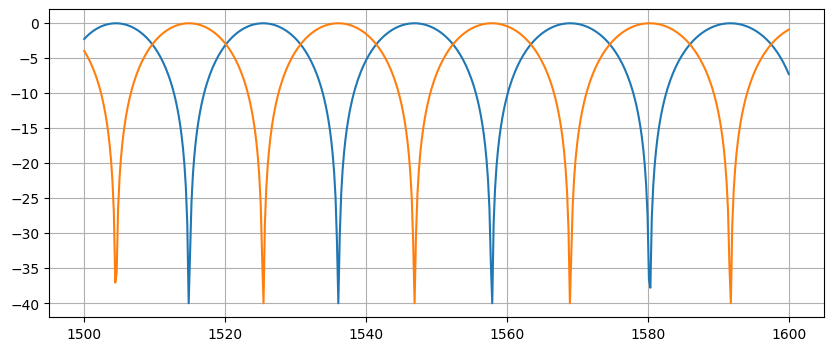

In [9]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, bar_port_db, label="Bar Port (dB)")
plt.plot(wl*1e9, cross_port_db, label="Cross Port (dB)")
plt.grid()